1: Setup and Data Loading

In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import time

# Set seeds for 100% reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# File dictionary - ensure these files are uploaded to your Colab environment
files = {
    40: "Grain2nm_lg16nm_weff40_vth_ion_ioff_simulated.csv",
    52: "Grain2nm_lg16nm_weff52_vth_ion_ioff_simulated.csv",
    60: "Grain2nm_lg16nm_weff60_vth_ion_ioff_simulated.csv"
}

dfs = []
for weff, file in files.items():
    # Load and skip metadata rows
    temp_df = pd.read_csv(file, header=2)
    temp_df = temp_df.loc[:, ~temp_df.columns.str.contains('^Unnamed')]
    temp_df['Weff'] = weff
    dfs.append(temp_df)

master_df = pd.concat(dfs, ignore_index=True)

# ROBUST CLEANING: Fixes the 'float has no attribute log10' error
master_df['OnCurrent'] = pd.to_numeric(master_df['OnCurrent'], errors='coerce')
master_df['OffCurrent'] = pd.to_numeric(master_df['OffCurrent'], errors='coerce')
master_df.dropna(subset=['OnCurrent', 'OffCurrent', 'Vth'], inplace=True)

# Convert to float64 explicitly to ensure numpy ufunc compatibility
master_df['log_Ioff'] = np.log10(master_df['OffCurrent'].values.astype(np.float64))
master_df['log_Ion'] = np.log10(master_df['OnCurrent'].values.astype(np.float64))

print(f"Cleaned dataset: {len(master_df)} samples available.")

Cleaned dataset: 598 samples available.


2: Model Architecture & Complexity Documentation

In [7]:
def build_improved_model(num_seeds):
    # Branch 1: Numerical (Geometry)
    input_weff = layers.Input(shape=(1,), name='Weff_Input')
    dense_weff = layers.Dense(16, activation='relu')(input_weff)

    # Branch 2: Categorical (Grain Seed Signature)
    # Increased embedding to 20 dimensions for better variability capture
    input_seed = layers.Input(shape=(1,), name='Seed_Input')
    emb_seed = layers.Embedding(input_dim=num_seeds, output_dim=20)(input_seed)
    emb_seed = layers.Flatten()(emb_seed)

    # Merging and Deep Layers
    merged = layers.Concatenate()([dense_weff, emb_seed])
    x = layers.Dense(64, activation='relu')(merged)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dense(16, activation='relu')(x)

    output = layers.Dense(3, name='Output')(x) # Vth, log_Ioff, log_Ion

    model = models.Model(inputs=[input_weff, input_seed], outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

3: Training with 5-Fold CV & LR Decay

In [8]:
# Setup inputs
master_df['seed_idx'] = master_df['seed'].astype(int) - 1
num_seeds = master_df['seed'].nunique()
X_weff = master_df[['Weff']].values
X_seed = master_df['seed_idx'].values
Y_targets = master_df[['Vth', 'log_Ioff', 'log_Ion']].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scaler_w = StandardScaler()
scaler_y = StandardScaler()
all_fold_data = []

start_time = time.time()

for fold, (train_idx, test_idx) in enumerate(kf.split(X_weff)):
    print(f"Training Fold {fold+1}/5...")

    # Scale within the fold to avoid data leakage
    X_w_train = scaler_w.fit_transform(X_weff[train_idx])
    X_w_test = scaler_w.transform(X_weff[test_idx])
    Y_train_scaled = scaler_y.fit_transform(Y_targets[train_idx])

    model = build_improved_model(num_seeds)

    # Improvement: LR Decay helps the model settle into a better minimum
    lr_decay = callbacks.ReduceLROnPlateau(monitor='loss', factor=0.5, patience=15, min_lr=1e-5)

    model.fit(
        [X_w_train, X_seed[train_idx]], Y_train_scaled,
        epochs=500, batch_size=16, verbose=0, callbacks=[lr_decay]
    )

    # Predictions
    preds_scaled = model.predict([X_w_test, X_seed[test_idx]])
    preds = scaler_y.inverse_transform(preds_scaled)

    # Store results
    fold_results = pd.DataFrame(preds, columns=['Vth_Pred', 'log_Ioff_Pred', 'log_Ion_Pred'])
    fold_results[['Vth_Sim', 'log_Ioff_Sim', 'log_Ion_Sim']] = Y_targets[test_idx]
    fold_results['Weff'] = X_weff[test_idx]
    all_fold_data.append(fold_results)

train_duration = time.time() - start_time
print(f"Total Training Time: {train_duration:.2f} seconds.")

# Combine all predictions for final reporting
final_df = pd.concat(all_fold_data, ignore_index=True)

Training Fold 1/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Training Fold 2/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Training Fold 3/5...


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Training Fold 4/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Training Fold 5/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Total Training Time: 316.68 seconds.


4: Data Export

---



In [9]:
# Convert back to physical Amperes for external plotting tools
final_df['Ioff_Sim_A'] = 10**final_df['log_Ioff_Sim']
final_df['Ioff_Pred_A'] = 10**final_df['log_Ioff_Pred']
final_df['Ion_Sim_A'] = 10**final_df['log_Ion_Sim']
final_df['Ion_Pred_A'] = 10**final_df['log_Ion_Pred']

# Save the necessary file
final_df.to_csv('TCAD_Surrogate_Validation_Results.csv', index=False)
print("File 'TCAD_Surrogate_Validation_Results.csv' saved. Share this with your supervisor.")

File 'TCAD_Surrogate_Validation_Results.csv' saved. Share this with your supervisor.


5: Final Scientific Plotting (Seaborn)

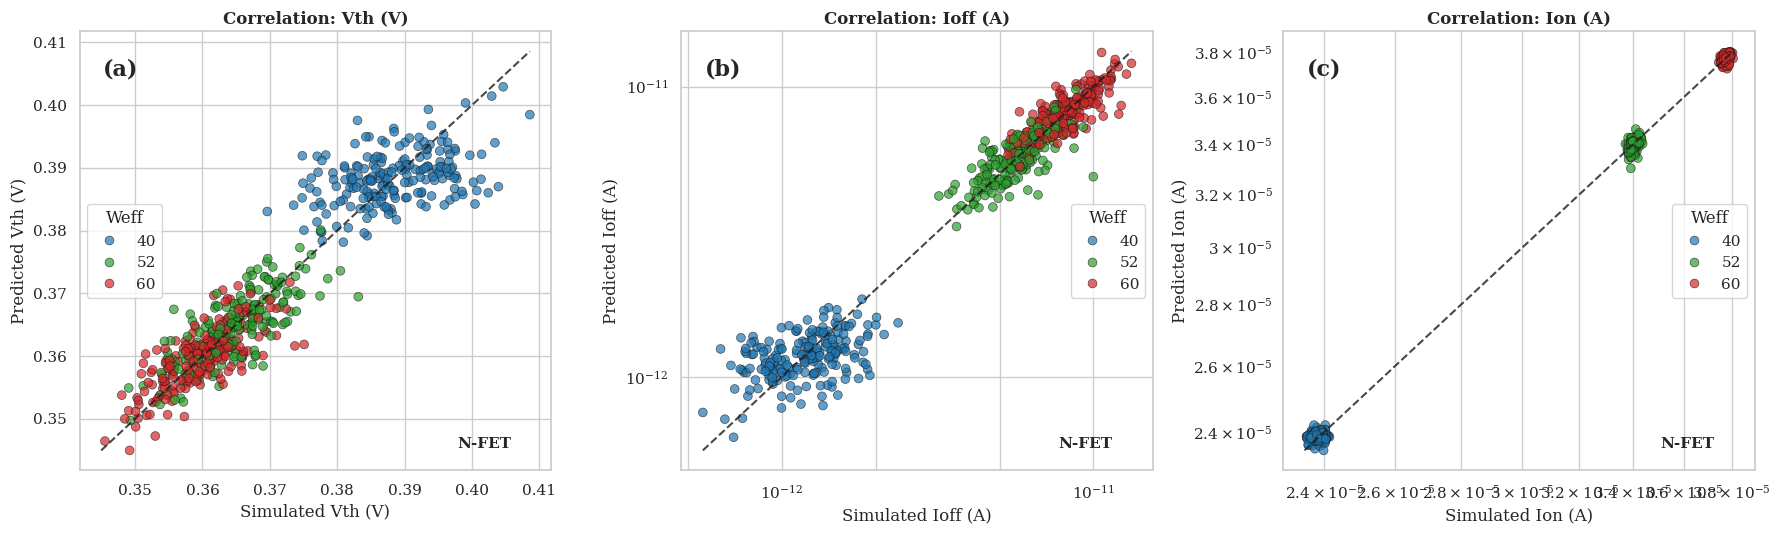

In [10]:
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif'
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

plot_configs = [
    ('Vth_Sim', 'Vth_Pred', 'Vth (V)', '(a)'),
    ('Ioff_Sim_A', 'Ioff_Pred_A', 'Ioff (A)', '(b)'),
    ('Ion_Sim_A', 'Ion_Pred_A', 'Ion (A)', '(c)')
]

for i, (sim, pred, label, tag) in enumerate(plot_configs):
    ax = axes[i]
    is_curr = (i > 0)

    sns.scatterplot(data=final_df, x=sim, y=pred, hue='Weff',
                    palette={40: '#1f77b4', 52: '#2ca02c', 60: '#d62728'},
                    ax=ax, s=40, alpha=0.7, edgecolor='k', linewidth=0.5)

    # Reference Line
    low = min(final_df[sim].min(), final_df[pred].min())
    high = max(final_df[sim].max(), final_df[pred].max())
    ax.plot([low, high], [low, high], 'k--', alpha=0.8)

    # Formatting
    ax.set_title(f'Correlation: {label}', fontweight='bold')
    ax.set_xlabel(f'Simulated {label}'); ax.set_ylabel(f'Predicted {label}')
    ax.text(0.05, 0.9, tag, transform=ax.transAxes, fontsize=16, fontweight='bold')
    ax.text(0.8, 0.05, 'N-FET', transform=ax.transAxes, fontsize=11, fontweight='bold')

    if is_curr:
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
        ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
        ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=(1.0, 2.0, 5.0), numticks=10))

plt.tight_layout()
plt.savefig('Final_Surrogate_Correlations.png', dpi=300)
plt.show()

Aggregated Accuracy Metrics

In [11]:
from sklearn.metrics import mean_squared_error, r2_score

# Define the evaluation pairs based on the final_df columns
evaluation_pairs = [
    ('Vth_Sim', 'Vth_Pred', 'Vth (V)'),
    ('log_Ioff_Sim', 'log_Ioff_Pred', 'log_Ioff'),
    ('log_Ion_Sim', 'log_Ion_Pred', 'log_Ion')
]

print("="*50)
print(f"{'Parameter':<15} | {'RMSE':<10} | {'R2 Score':<10}")
print("-" * 50)

results_summary = []

for sim, pred, label in evaluation_pairs:
    rmse = np.sqrt(mean_squared_error(final_df[sim], final_df[pred]))
    r2 = r2_score(final_df[sim], final_df[pred])
    results_summary.append({'Param': label, 'RMSE': rmse, 'R2': r2})
    print(f"{label:<15} | {rmse:<10.5f} | {r2:<10.5f}")

print("="*50)

Parameter       | RMSE       | R2 Score  
--------------------------------------------------
Vth (V)         | 0.00488    | 0.87768   
log_Ioff        | 0.07773    | 0.95806   
log_Ion         | 0.00239    | 0.99922   


Getting the merged + preprocessed dataset


In [12]:
import pandas as pd

# 1. Define the simulation files for each effective width (Weff)
files = {
    40: "Grain2nm_lg16nm_weff40_vth_ion_ioff_simulated.csv",
    52: "Grain2nm_lg16nm_weff52_vth_ion_ioff_simulated.csv",
    60: "Grain2nm_lg16nm_weff60_vth_ion_ioff_simulated.csv"
}

dfs = []

# 2. Load each file and tag it with its respective Weff
for weff, file in files.items():
    # Note: Simulations typically have metadata in the first 2 rows, so we start at row 2
    temp_df = pd.read_csv(file, header=2)

    # Remove unnamed or empty columns
    temp_df = temp_df.loc[:, ~temp_df.columns.str.contains('^Unnamed')]

    # Add the Weff column as a feature
    temp_df['Weff'] = weff
    dfs.append(temp_df)

# 3. Merge all datasets into one master dataframe
master_df = pd.concat(dfs, ignore_index=True)

# 4. Data Cleaning: Ensure currents are numeric and remove any invalid rows
master_df['OnCurrent'] = pd.to_numeric(master_df['OnCurrent'], errors='coerce')
master_df['OffCurrent'] = pd.to_numeric(master_df['OffCurrent'], errors='coerce')
master_df.dropna(inplace=True)

# 5. Export the merged dataset to a CSV file
master_df.to_csv('TCAD_Merged_Master_Dataset.csv', index=False)

print(f"Success! Merged dataset saved as 'TCAD_Merged_Master_Dataset.csv' with {len(master_df)} samples.")

Success! Merged dataset saved as 'TCAD_Merged_Master_Dataset.csv' with 598 samples.
